In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [2]:
def load_img():
    blank_img=np.zeros((600,600))
    font=cv2.FONT_HERSHEY_SIMPLEX
    cv2.putText(blank_img,text='VIKAA',org=(50,300),fontFace=font,fontScale=5,color=(255,255,255),thickness=25,lineType=cv2.LINE_AA)
    return blank_img

In [3]:
def display_img(img):
    fig=plt.figure(figsize=(12,10))
    ax=fig.add_subplot(111)
    ax.imshow(img,cmap='gray')
    plt.show()

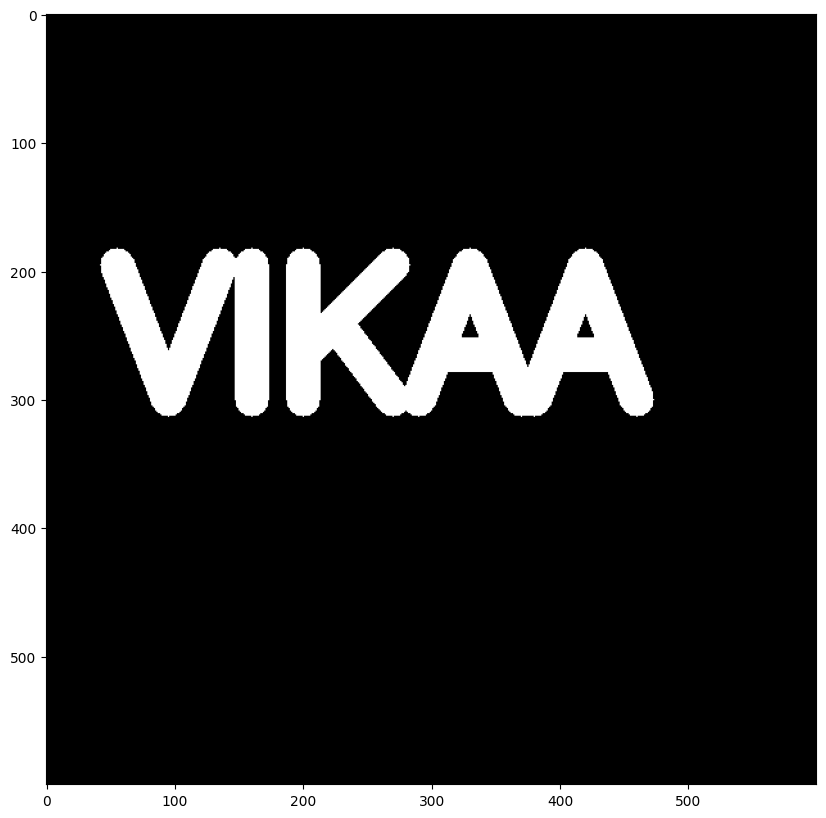

In [4]:
img=load_img()
display_img(img)

In [5]:
kernel=np.ones((5,5),dtype=np.uint8)
kernel

array([[1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1]], dtype=uint8)

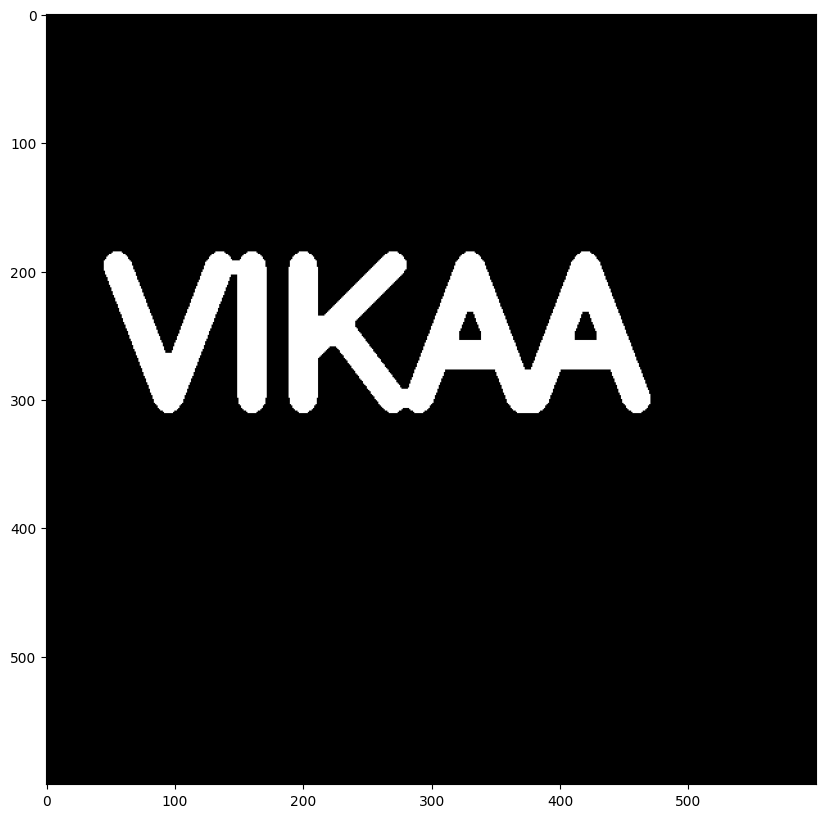

In [6]:
erosion1=cv2.erode(img,kernel,iterations=1)
display_img(erosion1)

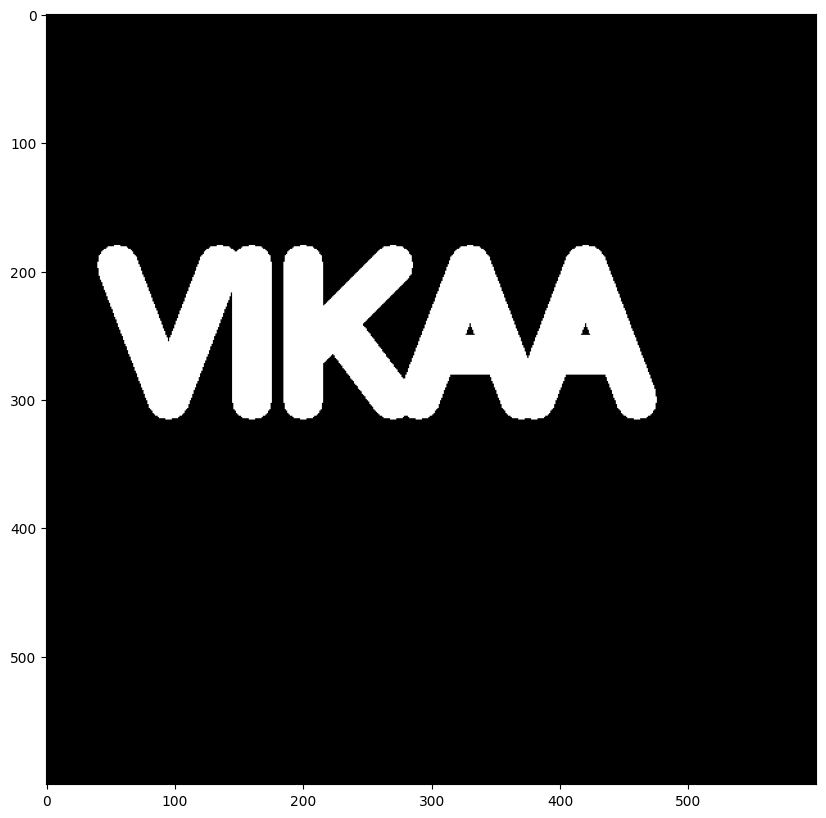

In [7]:
dilu=cv2.dilate(img,kernel,iterations=1)
display_img(dilu)

In [8]:
white_noise=np.random.randint(low=0,high=2,size=(600,600))
white_noise

array([[1, 1, 1, ..., 1, 1, 0],
       [0, 1, 0, ..., 1, 0, 1],
       [0, 0, 1, ..., 1, 0, 0],
       ...,
       [0, 0, 0, ..., 1, 1, 0],
       [0, 0, 1, ..., 1, 1, 1],
       [0, 1, 1, ..., 0, 0, 1]], shape=(600, 600), dtype=int32)

In [9]:
img.max()

np.float64(255.0)

In [10]:
white_noise.max()

np.int32(1)

In [11]:
white_noise *=255
img.shape

(600, 600)

In [12]:
white_noise

array([[255, 255, 255, ..., 255, 255,   0],
       [  0, 255,   0, ..., 255,   0, 255],
       [  0,   0, 255, ..., 255,   0,   0],
       ...,
       [  0,   0,   0, ..., 255, 255,   0],
       [  0,   0, 255, ..., 255, 255, 255],
       [  0, 255, 255, ...,   0,   0, 255]], shape=(600, 600), dtype=int32)

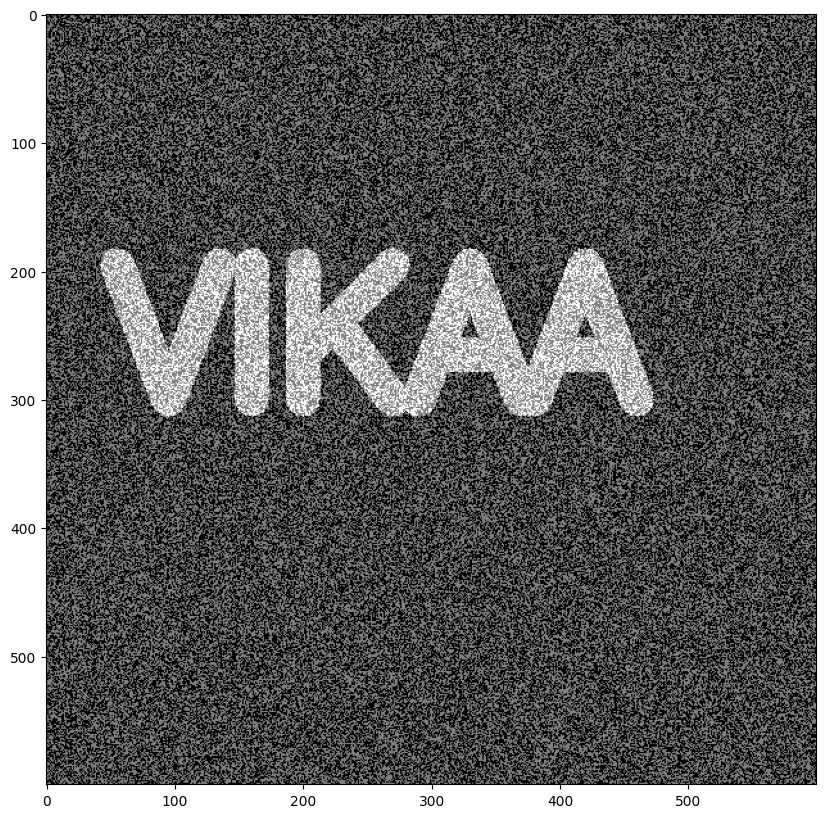

In [13]:
noise_img=white_noise+img
display_img(noise_img)

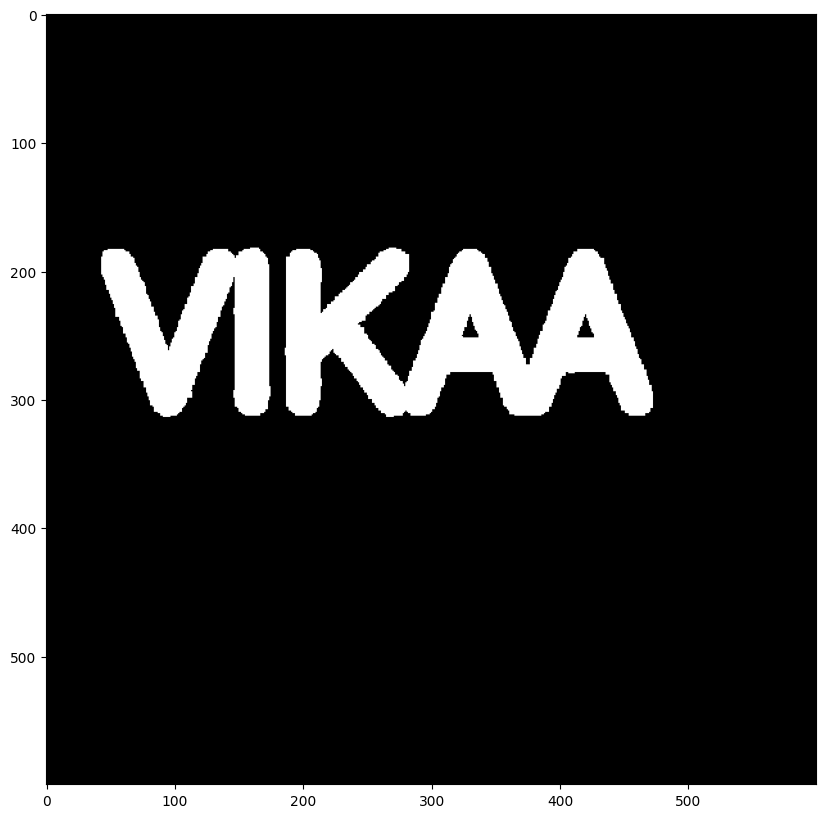

In [14]:
opening=cv2.morphologyEx(noise_img,cv2.MORPH_OPEN,kernel)
display_img(opening)

In [15]:
black_noise=np.random.randint(low=0,high=2,size=(600,600))
black_noise

array([[0, 0, 0, ..., 1, 0, 0],
       [0, 1, 1, ..., 0, 0, 0],
       [1, 1, 0, ..., 0, 1, 1],
       ...,
       [1, 1, 1, ..., 0, 1, 1],
       [0, 0, 1, ..., 1, 1, 0],
       [0, 1, 1, ..., 1, 1, 0]], shape=(600, 600), dtype=int32)

In [16]:
black_noise*=-255
img.shape

(600, 600)

In [17]:
black_noise

array([[   0,    0,    0, ..., -255,    0,    0],
       [   0, -255, -255, ...,    0,    0,    0],
       [-255, -255,    0, ...,    0, -255, -255],
       ...,
       [-255, -255, -255, ...,    0, -255, -255],
       [   0,    0, -255, ..., -255, -255,    0],
       [   0, -255, -255, ..., -255, -255,    0]],
      shape=(600, 600), dtype=int32)

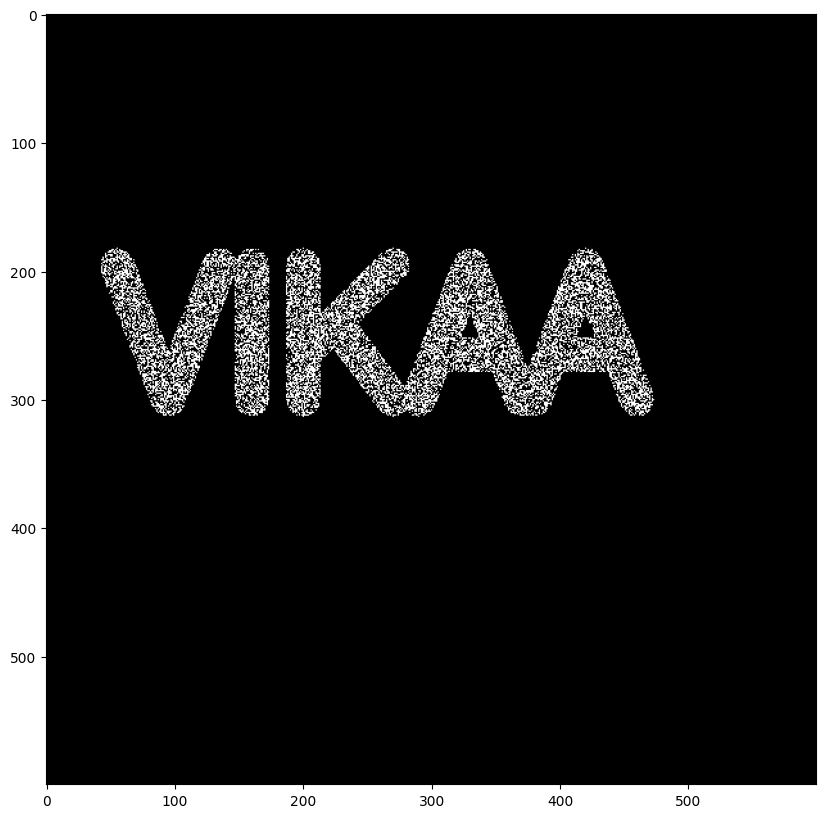

In [18]:
noise_img1=black_noise+img
noise_img1[noise_img1==-255]=0
display_img(noise_img1)

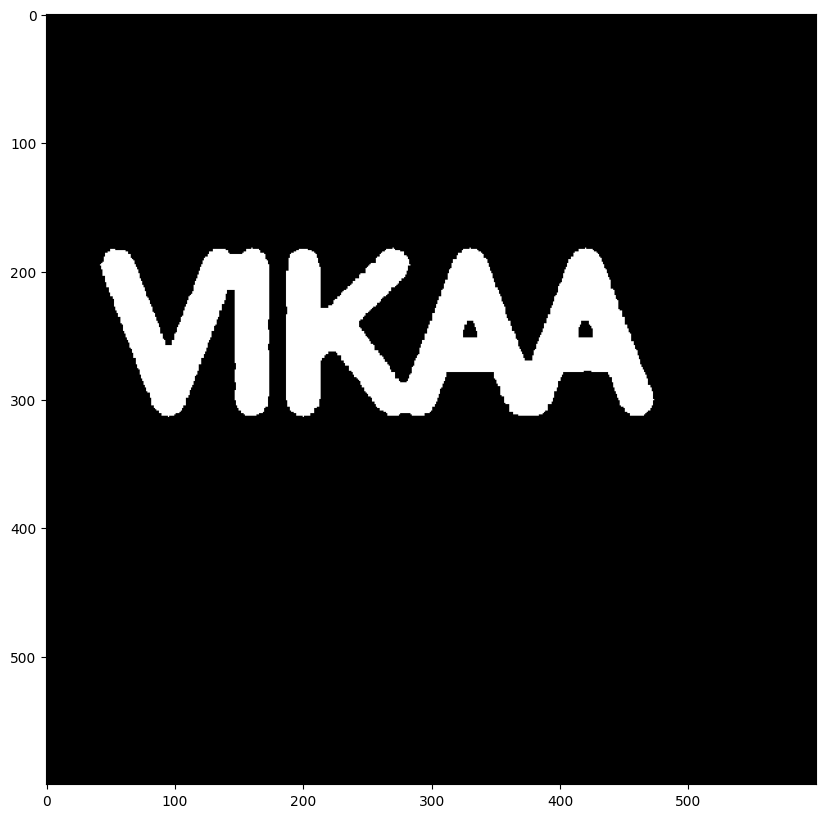

In [19]:
closing=cv2.morphologyEx(noise_img,cv2.MORPH_CLOSE,kernel)
display_img(closing)

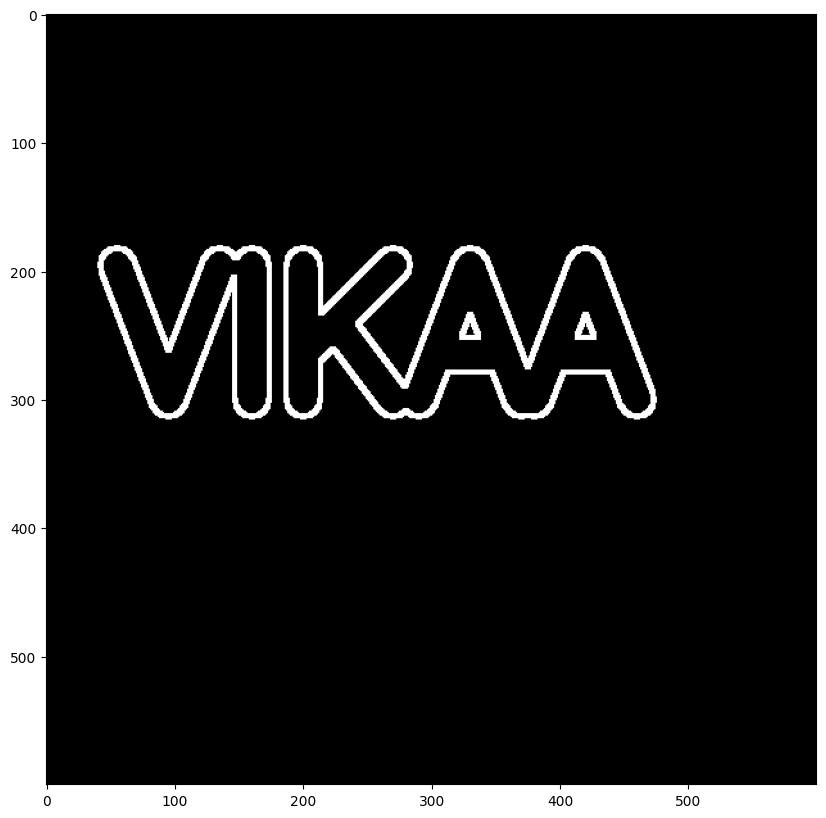

In [20]:
gradient = cv2.morphologyEx(img,cv2.MORPH_GRADIENT,kernel)
display_img(gradient)